### Exploratory Data Analysis umumnya untuk menjawab beberapa pertanyaan di bawah ini :

#### -Default Pattern Analysis

Apakah makin sering bayarnya telat makin tinggi default?

#### -Payment Behaviour

Total pemakaian tinggi apakah mengindikasikan tekanan finansial sehingga meningkatkan risiko default payment? 

#### -Financial Capacity

Debt ratio tinggi dan income yg rendah likely default?

#### -Credit Exposure

Terlalu banyak loan apakah meningkatkan risk dan terlalu sedikit mengurangi credit history

##### -Customer Profile

Banyak tanggungan semakin meningkat beban finansialnya


### Import Library

In [341]:
import pandas as pd 
import numpy as np 

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt



### 1. Load Data & Iniatial Inspection

In [342]:
# Melakukan loading dataset dari file CSV
df = pd.read_csv("cs-training.csv")
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [343]:
# Option B: Modifying in place
df.drop('Unnamed: 0', axis=1, inplace=True)
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [344]:
# Display jumlah data dan tipe data dari setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [345]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

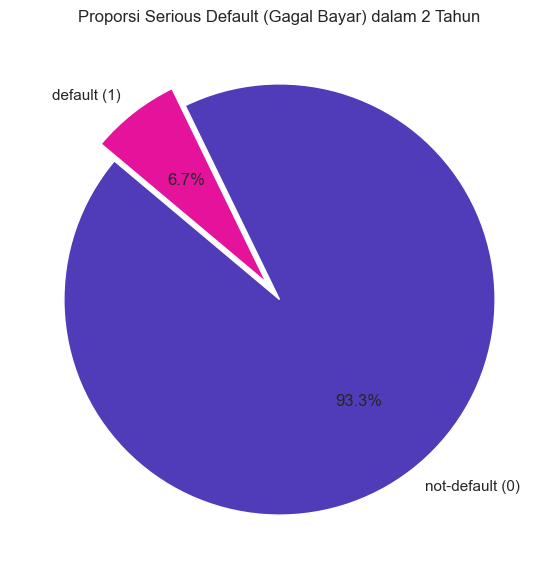

In [346]:

# Menghitung jumlah masing-masing kelas
data_pi = df['SeriousDlqin2yrs'].value_counts()

# Membuat Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(data_pi, 
        labels=['not-default (0)', 'default (1)'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=["#503BB9","#e5129b"], 
        explode=[0, 0.1])  # Memberikan sedikit jarak pada potongan 'Bad'

plt.title('Proporsi Serious Default (Gagal Bayar) dalam 2 Tahun')
plt.show()

##### Handle duplikasi

In [347]:
df.duplicated().sum()

609

In [348]:
df_no_dup = df.drop_duplicates()

In [349]:
df_no_dup.duplicated().sum()

0

### 2. Data Cleaning & Anomaly Handling

In [350]:
df_no_dup.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149391.0,0.066999,0.250021,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,149391.0,6.071087,250.263672,0.0,0.030132,0.154235,0.556494,50708.0
age,149391.0,52.306237,14.725962,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,149391.0,0.393886,3.852953,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,149391.0,354.436740,2041.843455,0.0,0.177441,0.368234,0.875279,329664.0
MonthlyIncome,120170.0,6675.098269,14389.582246,0.0,3400.000000,5400.000000,8250.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,149391.0,8.480892,5.136515,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,149391.0,0.238120,3.826165,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,149391.0,1.022391,1.130196,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,149391.0,0.212503,3.810523,0.0,0.000000,0.000000,0.000000,98.0


In [351]:
df_no_dup['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139382
1     10009
Name: count, dtype: int64

In [352]:
# 1. Validasi Statistik (IQR & Persentil)

def validate_constraints(df, column):
    # Hitung IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung Persentil Ekstrem
    p99 = df[column].quantile(0.99)
    p999 = df[column].quantile(0.999)
    
    print(f"=== Validasi Kolom: {column} ===")
    print(f"Batas Atas Statistik (Q3 + 1.5*IQR): {upper_bound:.2f}")
    print(f"Persentil 99% (P99)                : {p99:.2f}")
    print(f"Persentil 99.9% (P99.9)            : {p999:.2f}")
    print(f"Nilai Maksimum Saat Ini            : {df[column].max():.2f}")
    print("-" * 40)

# Jalankan validasi pada kolom utama menggunakan data df_no_dup
target_cols = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'age', 'MonthlyIncome']
for col in target_cols:
    validate_constraints(df_no_dup, col)

=== Validasi Kolom: RevolvingUtilizationOfUnsecuredLines ===
Batas Atas Statistik (Q3 + 1.5*IQR): 1.35
Persentil 99% (P99)                : 1.09
Persentil 99.9% (P99.9)            : 1574.66
Nilai Maksimum Saat Ini            : 50708.00
----------------------------------------
=== Validasi Kolom: DebtRatio ===
Batas Atas Statistik (Q3 + 1.5*IQR): 1.92
Persentil 99% (P99)                : 4985.10
Persentil 99.9% (P99.9)            : 10658.14
Nilai Maksimum Saat Ini            : 329664.00
----------------------------------------
=== Validasi Kolom: age ===
Batas Atas Statistik (Q3 + 1.5*IQR): 96.00
Persentil 99% (P99)                : 87.00
Persentil 99.9% (P99.9)            : 94.00
Nilai Maksimum Saat Ini            : 109.00
----------------------------------------
=== Validasi Kolom: MonthlyIncome ===
Batas Atas Statistik (Q3 + 1.5*IQR): 15525.00
Persentil 99% (P99)                : 25000.00
Persentil 99.9% (P99.9)            : 78434.26
Nilai Maksimum Saat Ini            : 3008750.00
--

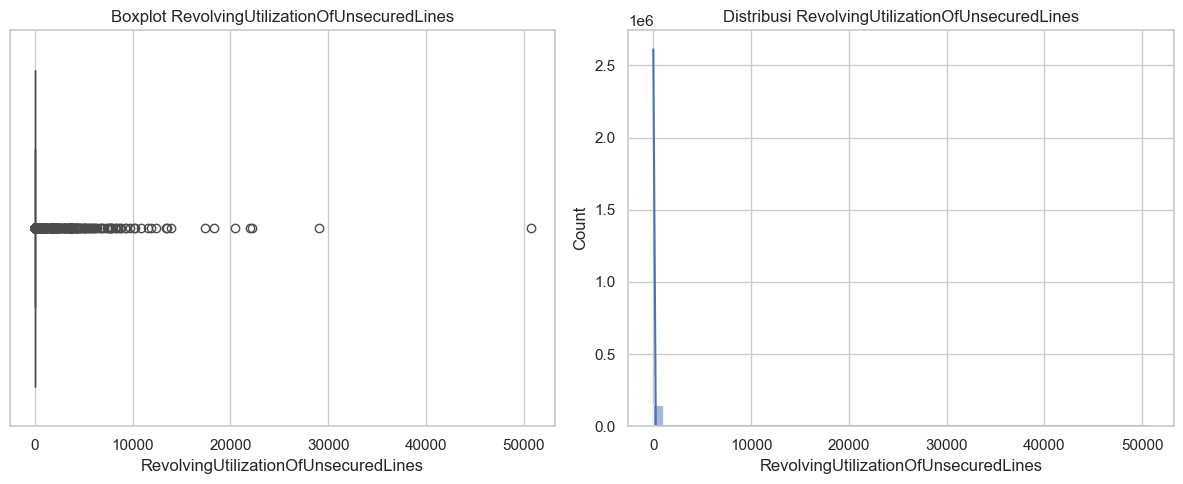

In [353]:
# 2. Visualisasi Sebaran


def plot_distribution(df, column):
    plt.figure(figsize=(12, 5))
    
    # Boxplot untuk melihat outlier secara visual
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot {column}')
    
    # Histogram untuk melihat konsentrasi data
    plt.subplot(1, 2, 2)
    sns.histplot(df[column], bins=50, kde=True)
    plt.title(f'Distribusi {column}')
    
    plt.tight_layout()
    plt.show()

# Contoh: Visualisasikan Revolving Utilization
plot_distribution(df_no_dup, 'RevolvingUtilizationOfUnsecuredLines')

Penjelasan :

- Menyaring Anomali yang Mustahil (Utilization > 10)

Logika Bisnis: Secara kredit, penggunaan di atas 100% (ratio > 1) sudah menunjukkan risiko tinggi. Angka 10 (1000%) adalah batas toleransi ekstra longgar.

Validasi hasil statistik di atas : Data menunjukkan 99% nasabah berada di bawah rasio 1.09, namun ada lonjakan ekstrem hingga 50.000. Menggunakan angka 10 memastikan kita hanya membuang system glitch tanpa menyentuh data perilaku manusia yang aslinya.

- Membersihkan delay (terlambat sebanyak 96/98 kali)

Logika Bisnis: Tidak logis/tidak lumrah seseorang terlambat bayar 98 kali(hitungannya ~24 tahun)

Validasi hasil statistik di atas : Angka 96 dan 98 muncul sebagai lonjakan tiba-tiba di ujung distribusi. Ini adalah kode sistem untuk "Data Tidak Tersedia". Menjadikannya NaN mencegah untuk salah mengartikan kode ini sebagai jumlah keterlambatan nyata.

- Koreksi Rasio Hutang yang besar (Debt Ratio > 1)

Logika Bisnis: Secara ekonomi, cicilan yang melebihi 100% pendapatan adalah kondisi gagal bayar.

Validasi hasil statistik di atas : Lonjakan angka ribuan pada kolom ini terjadi karena kolom pendapatan (Monthly Income) kosong, sehingga rumusnya rusak (pembagian dengan nol). Membatasi di angka 1 mengembalikan integritas variabel agar model belajar dari rasio kemampuan bayar yang masuk akal.

- Mengubah Kehilangan Data Menjadi Informasi (Flagging) dilakukan di monthlyincome

Logika Bisnis: Nasabah yang tidak mencantumkan gaji memiliki profil risiko yang berbeda (seringkali lebih berisiko atau justru sangat mapan).

Validasi hasil statistik di atas: Daripada hanya menebak nilai gaji yang hilang, pembuatan kolom baru (Flag 0/1) mengubah "masalah data" menjadi fitur prediktif baru. Ini menangkap sinyal perilaku nasabah yang sengaja menyembunyikan informasi.

In [354]:
df_clean = df_no_dup.copy()

#  Delay
cols_late = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in cols_late:
    df_clean.loc[df_clean[col] >= 90, col] = np.nan

#  RevolvingUtilization
df_clean.loc[df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10, 
             'RevolvingUtilizationOfUnsecuredLines'] = np.nan

#  DebtRatio
df_clean.loc[df_clean['DebtRatio'] > 1, 'DebtRatio'] = np.nan

#  Age
df_clean.loc[df_clean['age'] < 18, 'age'] = np.nan
df_clean.loc[df_clean['age'] > 100, 'age'] = np.nan

#  Optional (tidak wajib langsung)
df_clean.loc[df_clean['MonthlyIncome'] > 1_000_000, 'MonthlyIncome'] = np.nan
df_clean.loc[df_clean['NumberOfDependents'] > 10, 'NumberOfDependents'] = np.nan

# Pinjaman Properti (Anomali Ekstrem)
df_clean.loc[df_clean['NumberRealEstateLoansOrLines'] > 15, 'NumberRealEstateLoansOrLines'] = np.nan

# Catatan: NumberOfOpenCreditLinesAndLoans dibiarkan karena distribusi masih logis.

In [355]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149391.0,0.066999,0.250021,0.0,0.000000,0.000000,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,149150.0,0.322065,0.365943,0.0,0.030027,0.153564,0.553558,8.851852
age,149377.0,52.302115,14.718202,21.0,41.000000,52.000000,63.000000,99.000000
NumberOfTime30-59DaysPastDueNotWorse,149166.0,0.246725,0.698936,0.0,0.000000,0.000000,0.000000,13.000000
DebtRatio,114261.0,0.304590,0.225792,0.0,0.128991,0.275996,0.439161,1.000000
MonthlyIncome,120166.0,6613.444310,8714.406295,0.0,3400.000000,5400.000000,8250.000000,835040.000000
NumberOfOpenCreditLinesAndLoans,149391.0,8.480892,5.136515,0.0,5.000000,8.000000,11.000000,58.000000
NumberOfTimes90DaysLate,149166.0,0.090724,0.486352,0.0,0.000000,0.000000,0.000000,17.000000
NumberRealEstateLoansOrLines,149367.0,1.019014,1.093784,0.0,0.000000,1.000000,2.000000,15.000000
NumberOfTime60-89DaysPastDueNotWorse,149166.0,0.065068,0.330674,0.0,0.000000,0.000000,0.000000,11.000000


### 3. Handle Missing Values

In [356]:
df_clean.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines      241
age                                        14
NumberOfTime30-59DaysPastDueNotWorse      225
DebtRatio                               35130
MonthlyIncome                           29225
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   225
NumberRealEstateLoansOrLines               24
NumberOfTime60-89DaysPastDueNotWorse      225
NumberOfDependents                       3830
dtype: int64

In [357]:
(df_clean.isna().sum() / len(df_clean)).sort_values(ascending=False)

DebtRatio                               0.235155
MonthlyIncome                           0.195628
NumberOfDependents                      0.025637
RevolvingUtilizationOfUnsecuredLines    0.001613
NumberOfTime30-59DaysPastDueNotWorse    0.001506
NumberOfTimes90DaysLate                 0.001506
NumberOfTime60-89DaysPastDueNotWorse    0.001506
NumberRealEstateLoansOrLines            0.000161
age                                     0.000094
SeriousDlqin2yrs                        0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
dtype: float64

##### - Berdasarkan hasil yang didapat handle untuk revolvingUtilation, age, delay <1% dengan imputasi sederhana dengan median

##### - Berdasarkan hasil yang didapat handle Missing sedang (~2–3%) -> NumberOfDependents antara median/ 0

##### - Berdasarkan hasil yang didapat handle MonthlyIncome (~19%), (DebtRatio (~23%) isi NAN jika income juga missing, kalau tidak imputasi ringan)

In [358]:
# kecil → isi median
df_clean['RevolvingUtilizationOfUnsecuredLines'].fillna(
    df_clean['RevolvingUtilizationOfUnsecuredLines'].median(), inplace=True)

df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

df_clean['NumberOfDependents'].fillna(
    df_clean['NumberOfDependents'].median(), inplace=True)



C:\Users\HP\AppData\Local\Temp\ipykernel_16272\2136242766.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['RevolvingUtilizationOfUnsecuredLines'].fillna(
C:\Users\HP\AppData\Local\Temp\ipykernel_16272\2136242766.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [359]:
df_clean[df_clean['MonthlyIncome'].isna()]['DebtRatio'].describe()

count    1328.000000
mean        0.152871
std         0.359985
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: DebtRatio, dtype: float64

In [360]:
# kalau income missing → debt ratio juga dibuat NaN
df_clean.loc[df_clean['MonthlyIncome'].isna(), 'DebtRatio'] = np.nan

In [361]:
# TETAP NaN + tambahkan flag, NaN → 1 , Tidak NaN → 0
df_clean['income_missing_flag'] = df_clean['MonthlyIncome'].isna().astype(int)

In [362]:
df_clean.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      225
DebtRatio                               36458
MonthlyIncome                           29225
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   225
NumberRealEstateLoansOrLines               24
NumberOfTime60-89DaysPastDueNotWorse      225
NumberOfDependents                          0
income_missing_flag                         0
dtype: int64

### 4.Exploratory Data Analysis

In [363]:
df_clean.groupby('income_missing_flag')['SeriousDlqin2yrs'].mean()

income_missing_flag
0    0.069529
1    0.056595
Name: SeriousDlqin2yrs, dtype: float64

### Visualisasi

#### 1. Default Pattern Analysis

In [364]:
df_viz = df_clean.copy()

In [365]:
# buat kategori dan isi NAN jadi "Unknown"
df_viz['delay_bin'] = pd.cut(
    df_viz['NumberOfTimes90DaysLate'],
    bins=[-1, 0, 2, 5, 10, 20],
    labels=['0', '1-2', '3-5', '6-10', '>10']
)

df_viz['delay_bin'] = df_viz['delay_bin'].astype(str)
df_viz.loc[df_viz['NumberOfTimes90DaysLate'].isna(), 'delay_bin'] = 'Unknown'


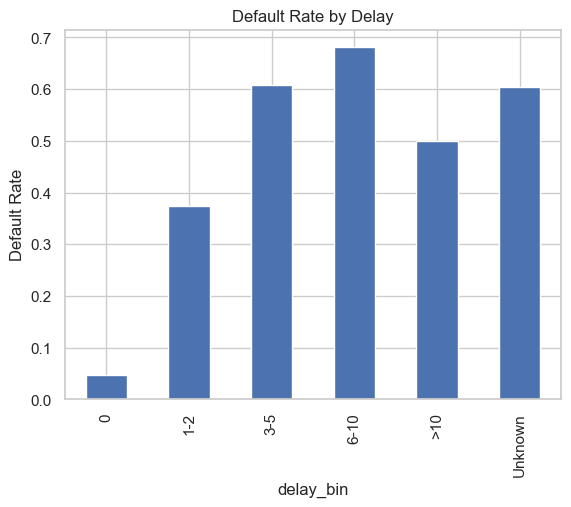

In [366]:
delay = df_viz.groupby('delay_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
delay.plot(kind='bar')
plt.title('Default Rate by Delay')
plt.ylabel('Default Rate')
plt.show()

#### Insight : 

Dari hasil visualisasi di atas dapat terlihat delay/terlambat bayar 90 hari merupakan perdiktor kuat apakah nasabah kemungkinan akan gagal bayar atau tidak, ada beberapa poin menarik dari semakin lama menunda pembayaran/delay sampai 6-10 kali maka default rate makin naik, lalu saat >10 malah lebih rendah ini bisa terjadi karena beberapa alasan antara lain mungkin sample lebih sedikit atau bisa juga karena ada campur tangan/intervensi bank pada debitur yang sering telat, sedangkan untuk kategori unkwown default rate juga cukup tinggi, jadi memang lebih baik dikelompokkan unkown dibanding mengisi 0/median karena berdasarkan hasil mereka yang def rate-nya cenderung beresiko tinggi, kesimpulannya riwayat keterlambatan adalah prediktor yang kuat untuk menentukan apakah seseorang akan mengalami default.

#### 2. Payment Behavior, Utilization (Penggunaan kredit)

C:\Users\HP\AppData\Local\Temp\ipykernel_16272\138926641.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util = df_viz.groupby('util_bin')['SeriousDlqin2yrs'].mean()


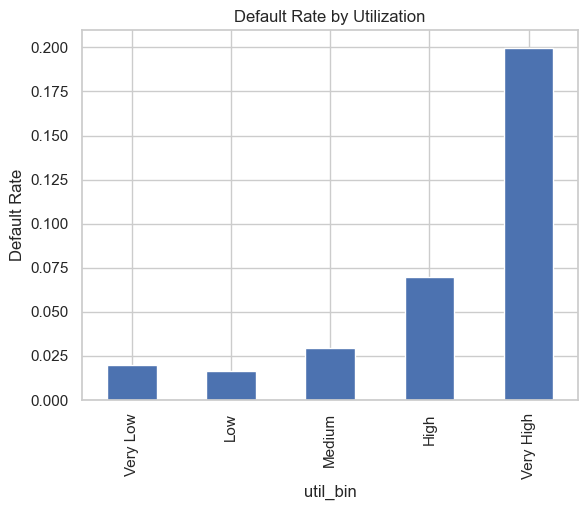

In [367]:
df_viz['util_bin'] = pd.qcut(
    df_viz['RevolvingUtilizationOfUnsecuredLines'],
    5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

util = df_viz.groupby('util_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
util.plot(kind='bar')
plt.title('Default Rate by Utilization')
plt.ylabel('Default Rate')
plt.show()

#### Insight : 

berdasarkan grafik di atas terlihat bahwa penggunaan kredit tinggi maka resiko default meningkat

#### 3. Financial Capacity (sekaligus handle nan di MonthlyIncome yang awalnya dibiarkan NAN untuk menjaga integritas data, jadi untuk visualisasi ini dijadikan kategori Unknown)

In [368]:
df_viz['income_bin'] = pd.qcut(
    df_viz['MonthlyIncome'],
    4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

df_viz['income_bin'] = df_viz['income_bin'].astype(str)
df_viz.loc[df_viz['MonthlyIncome'].isna(), 'income_bin'] = 'Unknown'

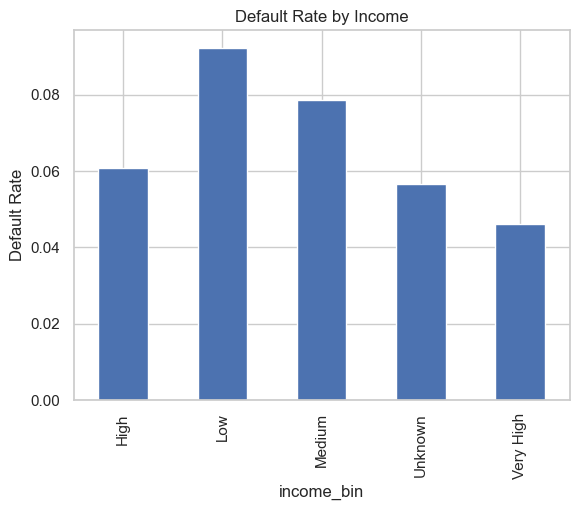

In [369]:
income = df_viz.groupby('income_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
income.plot(kind='bar')
plt.title('Default Rate by Income')
plt.ylabel('Default Rate')
plt.show()

#### Insight : 

Berdasarkan hasil maka income rendah cenderung memiliki default rate lebih tinggi.

4. Credit Exposure (jumlah kredit)

C:\Users\HP\AppData\Local\Temp\ipykernel_16272\1626572217.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan = df_viz.groupby('loan_bin')['SeriousDlqin2yrs'].mean()


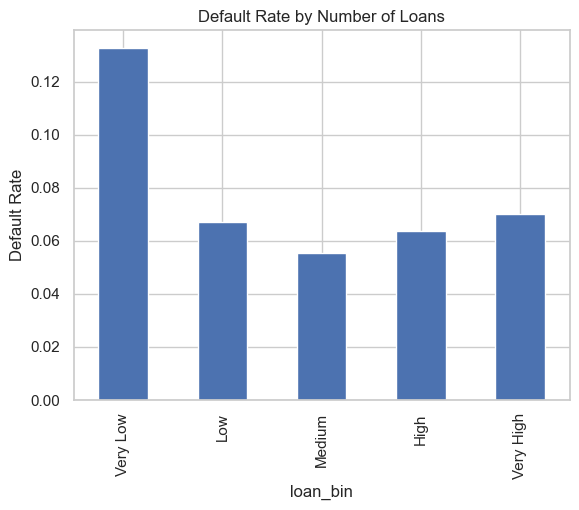

In [370]:
df_viz['loan_bin'] = pd.cut(
    df_viz['NumberOfOpenCreditLinesAndLoans'],
    bins=[-1, 2, 5, 10, 20, 60],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

loan = df_viz.groupby('loan_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
loan.plot(kind='bar')
plt.title('Default Rate by Number of Loans')
plt.ylabel('Default Rate')
plt.show()

In [371]:
df_viz['loan_bin'].value_counts()

loan_bin
Medium       60386
High         39030
Low          33474
Very Low     12521
Very High     3980
Name: count, dtype: int64

#### Insight : 

Terlalu sedikit akun(very low) resiko tinggi bisa jadi karena kurang riwayat atau nasabah baru yang belum teruji perilakunya dan dari datanya ada 12521 data yang menunjukan ada perilaku resiko di kelompok ini, jumlah akun/kredit ideal(medium) cenderung lebih stabil dan dapat dipercaya dan jumlah data ada 60386 cukup valid bahwa kelompok ini safe-zone, terlalu banyak(very high) mulai menunjukkan kenaikan peningkatan resiko dan terdapat 3980 data sample paling sedikit perlu diwaspadai



#### 5. Customer Profile (number of dependents)

C:\Users\HP\AppData\Local\Temp\ipykernel_16272\1877778790.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dep = df_viz.groupby('dep_bin')['SeriousDlqin2yrs'].mean()


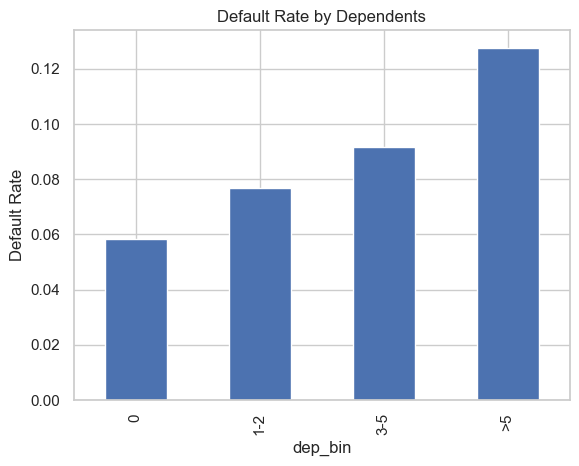

In [372]:
df_viz['dep_bin'] = pd.cut(
    df_viz['NumberOfDependents'],
    bins=[-1, 0, 2, 5, 10],
    labels=['0', '1-2', '3-5', '>5']
)

dep = df_viz.groupby('dep_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
dep.plot(kind='bar')
plt.title('Default Rate by Dependents')
plt.ylabel('Default Rate')
plt.show()

#### Insight : 

Semakin banyak tanggungan semakin tinggi resiko gagal bayar/resiko default naik karena beban finansial meningkat

#### Dashboard

C:\Users\HP\AppData\Local\Temp\ipykernel_16272\2640093700.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='age_bin', y='SeriousDlqin2yrs', data=df_dash, ax=axes[0,0], palette='viridis', ci=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_16272\2640093700.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_bin', y='SeriousDlqin2yrs', data=df_dash, ax=axes[0,0], palette='viridis', ci=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_16272\2640093700.py:40: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='income_bin', y='SeriousDlqin2yrs', data=df_dash, ax=axes[0,1], palette='magma', ci=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_16272\2640093700.py:40: FutureWarning: 

Passing `palette` without assigning `h

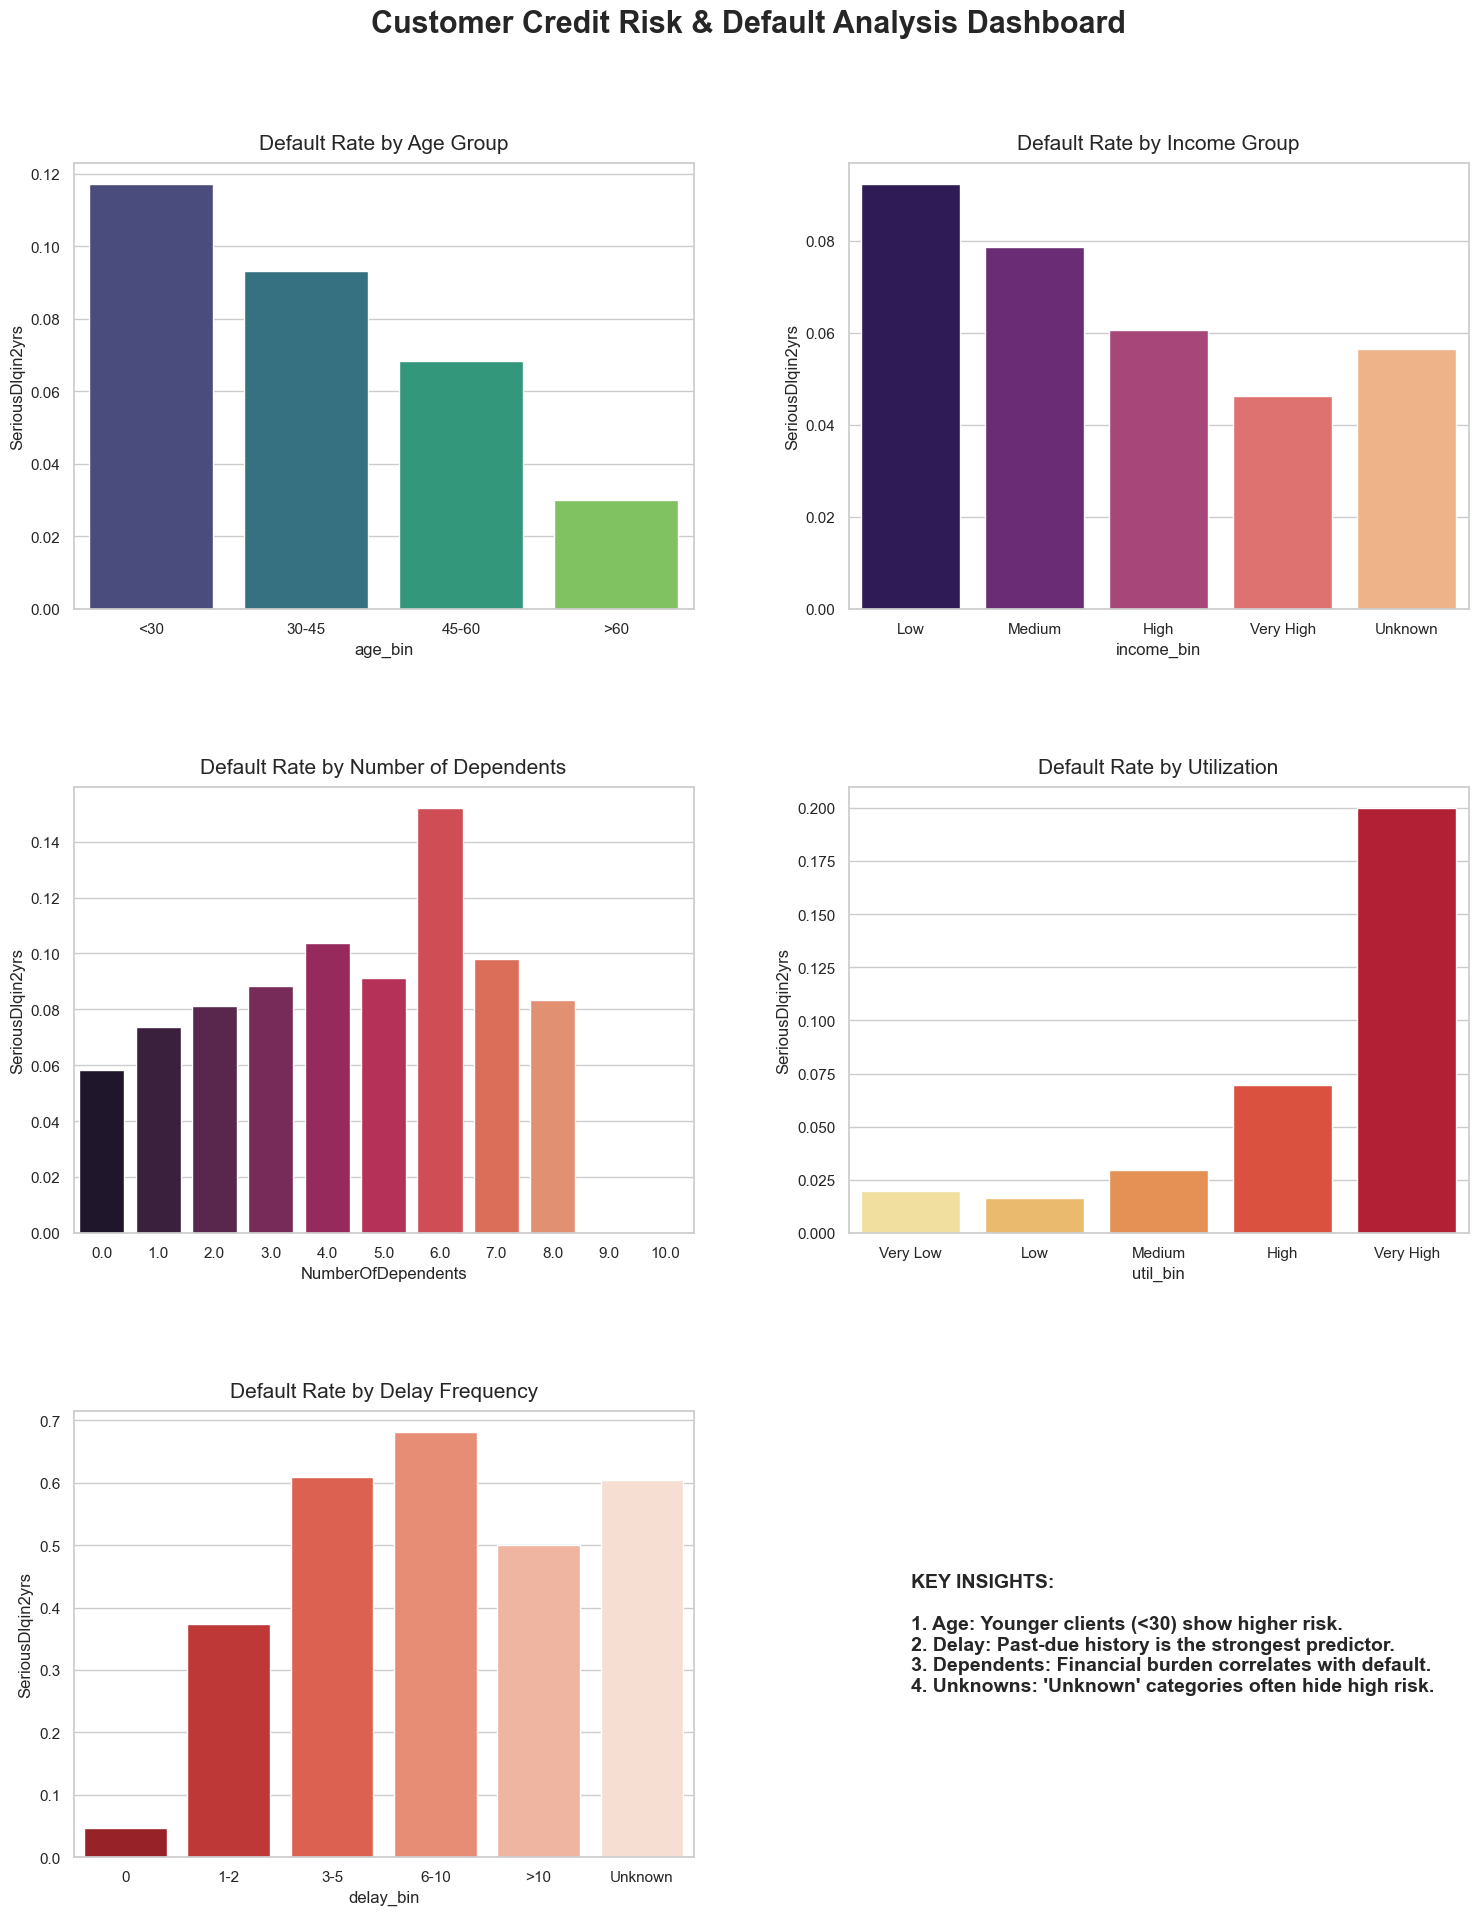

In [373]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Persiapan Data (Gunakan Copy agar df_viz asli tidak kotor)
df_dash = df_viz.copy()

# --- BINNING PROCESS ---

# A. Age Group
age_bins = [0, 30, 45, 60, 120]
age_labels = ['<30', '30-45', '45-60', '>60']
df_dash['age_bin'] = pd.cut(df_dash['age'], bins=age_bins, labels=age_labels)

# B. Income Group (Asumsi bins yang sudah ditentukan sebelumnya)
# Dalam income_bin, pastikan tipenya Categorical agar urut
income_order = ['Low', 'Medium', 'High', 'Very High', 'Unknown']
df_dash['income_bin'] = pd.Categorical(df_dash['income_bin'], categories=income_order, ordered=True)

# C. Utilization Group
util_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df_dash['util_bin'] = pd.Categorical(df_dash['util_bin'], categories=util_order, ordered=True)

# D. Delay Group (Asumsi kolom delay_bin)
delay_order = ['0', '1-2', '3-5', '6-10', '>10', 'Unknown']
df_dash['delay_bin'] = pd.Categorical(df_dash['delay_bin'], categories=delay_order, ordered=True)

# --- DASHBOARD VISUALIZATION ---

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
plt.subplots_adjust(hspace=0.4, wspace=0.25)
fig.suptitle('Customer Credit Risk & Default Analysis Dashboard', fontsize=22, fontweight='bold', y=0.95)

# Plot 1: Age Group (Filter 1)
sns.barplot(x='age_bin', y='SeriousDlqin2yrs', data=df_dash, ax=axes[0,0], palette='viridis', ci=None)
axes[0,0].set_title('Default Rate by Age Group', fontsize=15, pad=10)

# Plot 2: Income Group (Filter 2)
sns.barplot(x='income_bin', y='SeriousDlqin2yrs', data=df_dash, ax=axes[0,1], palette='magma', ci=None)
axes[0,1].set_title('Default Rate by Income Group', fontsize=15, pad=10)

# Plot 3: Dependents (Filter 3)
sns.barplot(x='NumberOfDependents', y='SeriousDlqin2yrs', data=df_dash, ax=axes[1,0], palette='rocket', ci=None)
axes[1,0].set_title('Default Rate by Number of Dependents', fontsize=15, pad=10)

# Plot 4: Utilization (Risk Pattern)
sns.barplot(x='util_bin', y='SeriousDlqin2yrs', data=df_dash, ax=axes[1,1], palette='YlOrRd', ci=None)
axes[1,1].set_title('Default Rate by Utilization', fontsize=15, pad=10)

# Plot 5: Delay Patterns (Risk Pattern)
sns.barplot(x='delay_bin', y='SeriousDlqin2yrs', data=df_dash, ax=axes[2,0], palette='Reds_r', ci=None)
axes[2,0].set_title('Default Rate by Delay Frequency', fontsize=15, pad=10)

# Plot 6: Placeholder atau Summary Text (Opsional)
axes[2,1].axis('off')
axes[2,1].text(0.1, 0.5, 
    "KEY INSIGHTS:\n\n"
    "1. Age: Younger clients (<30) show higher risk.\n"
    "2. Delay: Past-due history is the strongest predictor.\n"
    "3. Dependents: Financial burden correlates with default.\n"
    "4. Unknowns: 'Unknown' categories often hide high risk.",
    fontsize=14, fontweight='bold', verticalalignment='center', bbox=dict(facecolor='white', alpha=0.5))

plt.show()

In [374]:
print("\n" + "="*80)
print("KESIMPULAN AKHIR")
print("="*80)
print("""
Berdasarkan EDA yang telah dilakukan pada 150.000 data nasabah:

1. Keterlambatan pembayaran adalah prediktor terkuat default rate
2. Penggunaan kredit tinggi (>60%) mengindikasikan tekanan finansial
3. Income rendah dan debt ratio tinggi meningkatkan risiko default
4. Customer dengan tanggungan >2 orang memiliki risiko lebih tinggi
5.  very low dan high sama-sama berisiko, optimal di medium exposure

Dashboard di atas dapat digunakan untuk:
- Justifikasi fitur dalam model machine learning
- Menentukan threshold risiko untuk approval
- Segmentasi customer berdasarkan profil risiko
""")


KESIMPULAN AKHIR

Berdasarkan EDA yang telah dilakukan pada 150.000 data nasabah:

1. Keterlambatan pembayaran adalah prediktor terkuat default rate
2. Penggunaan kredit tinggi (>60%) mengindikasikan tekanan finansial
3. Income rendah dan debt ratio tinggi meningkatkan risiko default
4. Customer dengan tanggungan >2 orang memiliki risiko lebih tinggi
5.  very low dan high sama-sama berisiko, optimal di medium exposure

Dashboard di atas dapat digunakan untuk:
- Justifikasi fitur dalam model machine learning
- Menentukan threshold risiko untuk approval
- Segmentasi customer berdasarkan profil risiko

